# RQ1 — Chi è il pivot strutturale di ogni semifinalista?

## Obiettivo

Questa notebook implementa la prima research question del progetto:
**identificare il giocatore strutturalmente più importante in ogni rete di 
passaggio delle quattro semifinaliste del Mondiale 2022** (Argentina, Francia, 
Croazia, Marocco).

"Importante" in network science non ha un significato unico. Utilizziamo
sei definizioni diverse di centralità, ciascuna delle quali cattura un aspetto
diverso del ruolo di un giocatore nella rete. I giocatori su cui queste
definizioni **non concordano** sono il risultato più interessante dell'analisi.

## Struttura del notebook

1. Setup e importazioni
2. Caricamento dati StatsBomb
3. Costruzione della rete di passaggio
4. Calcolo delle sei centralità
5. Correlazioni di Spearman tra le misure
6. Identificazione dei profili strutturali (Terminal / Broker / Metronome)
7. Null model — verifica statistica
8. Visualizzazioni
9. Analisi aggregata sulle quattro semifinaliste

## 1. Setup e importazioni

Importiamo le librerie necessarie:

- `statsbombpy` — accesso ai dati open di StatsBomb direttamente in Python
- `networkx` — costruzione e analisi delle reti
- `pandas` / `numpy` — manipolazione dati
- `matplotlib` / `seaborn` — visualizzazioni
- `scipy` — correlazioni di Spearman
- `mplsoccer` — disegno del campo da calcio

In [20]:
import warnings
warnings.filterwarnings("ignore")

import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import spearmanr
from statsbombpy import sb
from mplsoccer import Pitch

# Configurazione globale
COMPETITION_ID = 43    # FIFA World Cup
SEASON_ID      = 106   # edizione 2022
SEMIFINALISTS  = ["Argentina", "France", "Croatia", "Morocco"]
MIN_MINUTES    = 30    # soglia minima di minuti per includere un giocatore

# Palette colori per le squadre e per i reparti
TEAM_COLORS = {
    "Argentina": "#75AADB",
    "France":    "#002395",
    "Croatia":   "#FF0000",
    "Morocco":   "#006233",
}

LINE_COLORS = {
    "GK":      "#FFD700",
    "DEF":     "#2196F3",
    "MID":     "#4CAF50",
    "ATT":     "#F44336",
    "Unknown": "#999999",
}

print("✓ Setup completato")

✓ Setup completato


## 2. Caricamento dati StatsBomb

StatsBomb mette a disposizione gratuitamente i dati event-level del Mondiale 2022.
Ogni evento rappresenta un'azione sul campo (passaggio, tiro, conduzione, ecc.)
con timestamp, coordinate x/y sul campo (120×80 metri), e metadati specifici
per il tipo di evento.
Per questa analisi ci interessano solo gli eventi di tipo **Pass** con
`pass_outcome` nullo, che in StatsBomb indica un passaggio **completato**.

- `pass_outcome` assente → passaggio completato ✓  
- `pass_outcome` presente ("Incomplete", "Out", ecc.) → passaggio fallito ✗

Iniziamo caricando la lista di tutte le 64 partite del torneo e identificando
le partite giocate da ciascuna delle quattro semifinaliste.

In [21]:
# Carica la lista di tutte le partite del Mondiale 2022
matches = sb.matches(competition_id=COMPETITION_ID, season_id=SEASON_ID)
print(f"Totale partite nel dataset: {len(matches)}")
print(f"Colonne disponibili: {matches.columns.tolist()}\n")

# Per ogni semifinalista, mostra le partite giocate
for team in SEMIFINALISTS:
    team_matches = matches[
        (matches["home_team"] == team) |
        (matches["away_team"] == team)
    ]
    print(f"{'─'*50}")
    print(f"{team}: {len(team_matches)} partite")
    for _, m in team_matches.iterrows():
        print(f"  [{m['match_id']}] {m['home_team']} vs {m['away_team']} — {m['competition_stage']}")

Totale partite nel dataset: 64
Colonne disponibili: ['match_id', 'match_date', 'kick_off', 'home_score', 'away_score', 'match_status', 'match_status_360', 'last_updated', 'last_updated_360', 'match_week', 'competition_id', 'competition_country_name', 'competition_name', 'competition', 'season_id', 'season', 'home_team_id', 'home_team', 'home_team_gender', 'home_team_group', 'home_team_country_id', 'home_team_country_name', 'away_team_id', 'away_team', 'away_team_gender', 'away_team_group', 'away_team_country_id', 'away_team_country_name', 'competition_stage_id', 'competition_stage', 'stadium_id', 'stadium', 'stadium_country_id', 'stadium_country_name', 'referee_id', 'referee', 'referee_country_id', 'referee_country_name', 'home_managers', 'away_managers', 'home_manager_id', 'home_manager_name', 'home_manager_nickname', 'home_manager_dob', 'home_manager_country_id', 'home_manager_country_name', 'away_manager_id', 'away_manager_name', 'away_manager_nickname', 'away_manager_dob', 'away_ma

## 3. Esplorazione della struttura degli eventi

Prima di costruire la rete, esploriamo la struttura di un singolo file di eventi
usando la **finale Argentina–Francia** come caso pilota.

Ogni file di eventi contiene tutte le azioni di una partita in ordine cronologico.
Vogliamo capire:
- Quanti eventi ci sono per partita
- Quanti sono passaggi completati
- Come sono strutturati i campi `player`, `pass_recipient`, `location`

Questo passaggio esplorativo è fondamentale prima di costruire qualsiasi rete:
conoscere i dati evita errori di interpretazione nelle analisi successive.

In [22]:
# Identifica il match_id della finale
finale_row = matches[matches["competition_stage"] == "Final"]
FINALE_ID = finale_row["match_id"].values[0]
print(f"Finale: {finale_row['home_team'].values[0]} vs "
      f"{finale_row['away_team'].values[0]} (match_id = {FINALE_ID})\n")

# Carica tutti gli eventi della finale
events_finale = sb.events(match_id=FINALE_ID)
print(f"Totale eventi nella partita: {len(events_finale)}")
print(f"\nDistribuzione per tipo di evento:")
print(events_finale["type"].value_counts().head(10))

Finale: Argentina vs France (match_id = 3869685)

Totale eventi nella partita: 4407

Distribuzione per tipo di evento:
type
Pass              1263
Ball Receipt*     1114
Carry              940
Pressure           361
Ball Recovery      115
Duel                98
Dribble             54
Block               50
Foul Committed      48
Clearance           45
Name: count, dtype: int64


In [23]:
# Filtra solo i passaggi e guarda la struttura
passes_raw = events_finale[events_finale["type"] == "Pass"].copy()

print(f"Totale passaggi (tutti):      {len(passes_raw)}")
print(f"Passaggi completati:          {passes_raw['pass_outcome'].isna().sum()}")
print(f"Passaggi falliti/incompleti:  {passes_raw['pass_outcome'].notna().sum()}")

print(f"\nEsempio di un passaggio completato:")
esempio = passes_raw[passes_raw["pass_outcome"].isna()].iloc[0]
print(f"  Giocatore:    {esempio['player']}")
print(f"  Ricevitore:   {esempio['pass_recipient']}")
print(f"  Squadra:      {esempio['team']}")
print(f"  Da:           {esempio['location']}")
print(f"  A:            {esempio['pass_end_location']}")

Totale passaggi (tutti):      1263
Passaggi completati:          994
Passaggi falliti/incompleti:  269

Esempio di un passaggio completato:
  Giocatore:    Antoine Griezmann
  Ricevitore:   Aurélien Djani Tchouaméni
  Squadra:      France
  Da:           [61.0, 40.1]
  A:            [48.0, 43.2]


## 4. Costruzione della rete di passaggio

Costruiamo la rete di passaggio per l'Argentina nella finale come caso pilota.
La rete è un **grafo diretto e pesato** dove:

- **Nodi** = giocatori
- **Archi** = direzione del passaggio (da chi passa → a chi riceve)
- **Peso dell'arco** = numero di passaggi completati tra quella coppia

### La convenzione della distanza: perché 1/peso

Le misure di betweenness e closeness centrality si basano sui **cammini più corti**
nella rete. Un algoritmo di cammino più corto cerca il percorso con la **somma
minima** dei pesi degli archi.

Nel nostro caso vogliamo che due giocatori che si scambiano molti passaggi siano
considerati **vicini**. Ma se usassimo il peso direttamente, un peso alto
significherebbe distanza alta — l'opposto di quello che vogliamo.

Soluzione: definiamo `distanza = 1 / peso`. Così:
- 20 passaggi tra A e B → distanza = 0.05 (vicini)
- 2 passaggi tra C e D  → distanza = 0.50 (lontani)

Questo è il bug più comune nella letteratura sulle reti di passaggio (Peña & 
Touchette, 2012) e viene corretto esplicitamente qui.

In [24]:
def build_passing_network(team_name, events_df):
    """
    Costruisce la rete di passaggio di una squadra da un DataFrame di eventi.
    
    Parametri
    ----------
    team_name : str
        Nome della squadra (come appare in StatsBomb)
    events_df : DataFrame
        Tutti gli eventi della partita
    
    Ritorna
    -------
    G : nx.DiGraph
        Grafo diretto e pesato con attributi 'weight' e 'distance' sugli archi
    passes_df : DataFrame
        DataFrame dei passaggi completati con coordinate
    """
    
    # Filtra: solo passaggi completati della squadra
    passes = events_df[
        (events_df["type"] == "Pass") &
        (events_df["team"] == team_name) &
        (events_df["pass_outcome"].isna())
    ].copy()
    
    # Estrai coordinate
    passes["x_start"] = passes["location"].apply(
        lambda l: l[0] if isinstance(l, list) else np.nan
    )
    passes["y_start"] = passes["location"].apply(
        lambda l: l[1] if isinstance(l, list) else np.nan
    )
    passes["x_end"] = passes["pass_end_location"].apply(
        lambda l: l[0] if isinstance(l, list) else np.nan
    )
    passes["y_end"] = passes["pass_end_location"].apply(
        lambda l: l[1] if isinstance(l, list) else np.nan
    )
    
    passes_clean = passes[
        ["player", "pass_recipient", "x_start", "y_start", "x_end", "y_end"]
    ].dropna(subset=["player", "pass_recipient"]).copy()
    passes_clean.columns = ["passer", "recipient", "x_start", "y_start", "x_end", "y_end"]
    
    # Conta i passaggi per ogni coppia (passer → recipient)
    edge_weights = (
        passes_clean
        .groupby(["passer", "recipient"])
        .size()
        .reset_index(name="weight")
    )
    
    # Calcola la posizione media di ogni giocatore sul campo
    avg_pos = (
        passes_clean
        .groupby("passer")[["x_start", "y_start"]]
        .mean()
        .rename(columns={"x_start": "avg_x", "y_start": "avg_y"})
    )
    
    # Costruisci il grafo
    G = nx.DiGraph()
    
    for _, row in edge_weights.iterrows():
        G.add_edge(
            row["passer"],
            row["recipient"],
            weight=row["weight"],
            distance=1.0 / row["weight"]   # convenzione fondamentale
        )
    
    # Aggiungi posizione media come attributo del nodo
    for node in G.nodes():
        if node in avg_pos.index:
            G.nodes[node]["avg_x"] = avg_pos.loc[node, "avg_x"]
            G.nodes[node]["avg_y"] = avg_pos.loc[node, "avg_y"]
        else:
            G.nodes[node]["avg_x"] = 60.0
            G.nodes[node]["avg_y"] = 40.0
    
    return G, passes_clean


# Test sulla finale dell'Argentina
G_arg_finale, passes_arg_finale = build_passing_network("Argentina", events_finale)

print(f"Rete Argentina (finale):")
print(f"  Nodi (giocatori):  {G_arg_finale.number_of_nodes()}")
print(f"  Archi (coppie):    {G_arg_finale.number_of_edges()}")
print(f"  Passaggi totali:   {sum(d['weight'] for _,_,d in G_arg_finale.edges(data=True))}")

Rete Argentina (finale):
  Nodi (giocatori):  17
  Archi (coppie):    129
  Passaggi totali:   560


## 5. Calcolo delle sei centralità

Calcoliamo le sei misure di centralità per ogni giocatore nella rete.
Ogni misura risponde a una domanda diversa:

| Misura | Domanda | Distanza usata |
|--------|---------|----------------|
| **In-Degree pesato** | Quanti passaggi riceve? | — |
| **Out-Degree pesato** | Quanti passaggi fa? | — |
| **Betweenness** | Su quanti cammini più corti si trova? | 1/weight ✓ |
| **Closeness** | Quanto è vicino a tutti gli altri? | 1/weight ✓ |
| **Eigenvector** | È connesso a giocatori importanti? | weight |
| **PageRank** | Qual è la prob. di avere il pallone? | weight |

Le misure che usano i cammini più corti (betweenness e closeness) **devono**
usare `distance = 1/weight`. Le altre usano il peso direttamente.

In [25]:
def compute_centralities(G):
    """
    Calcola le 6 misure di centralità su un grafo diretto e pesato.
    
    Ritorna un DataFrame con una riga per giocatore e 6 colonne di centralità,
    ordinato per betweenness decrescente.
    """
    
    total_w = sum(d["weight"] for _,_,d in G.edges(data=True))
    
    # 1. In-degree pesato (normalizzato)
    in_deg = {
        n: sum(d["weight"] for _,_,d in G.in_edges(n, data=True)) / total_w
        for n in G.nodes()
    }
    
    # 2. Out-degree pesato (normalizzato)
    out_deg = {
        n: sum(d["weight"] for _,_,d in G.out_edges(n, data=True)) / total_w
        for n in G.nodes()
    }
    
    # 3. Betweenness — usa DISTANCE
    betweenness = nx.betweenness_centrality(
        G, weight="distance", normalized=True
    )
    
    # 4. Closeness — usa DISTANCE
    closeness = nx.closeness_centrality(G, distance="distance")
    
    # 5. Eigenvector — usa weight
    try:
        eigenvector = nx.eigenvector_centrality(
            G, weight="weight", max_iter=1000
        )
    except nx.PowerIterationFailedConvergence:
        eigenvector = nx.eigenvector_centrality_numpy(G, weight="weight")
    
    # 6. PageRank — usa weight
    pagerank = nx.pagerank(G, weight="weight", alpha=0.85)
    
    # Assembla in DataFrame
    df = pd.DataFrame({
        "in_degree":   in_deg,
        "out_degree":  out_deg,
        "betweenness": betweenness,
        "closeness":   closeness,
        "eigenvector": eigenvector,
        "pagerank":    pagerank,
    })
    
    return df.sort_values("betweenness", ascending=False)


# Calcola le centralità per l'Argentina nella finale
cent_arg = compute_centralities(G_arg_finale)

print("Argentina (finale) — Top 10 per betweenness:\n")
print(cent_arg.round(4).to_string())

Argentina (finale) — Top 10 per betweenness:

                                 in_degree  out_degree  betweenness  closeness  eigenvector  pagerank
Nicolás Hernán Otamendi             0.1071      0.1232       0.3625     2.8586       0.3337    0.0992
Enzo Fernandez                      0.1500      0.1411       0.3542     3.0765       0.4620    0.1435
Rodrigo Javier De Paul              0.1179      0.1018       0.1354     2.9095       0.4260    0.1038
Alexis Mac Allister                 0.0821      0.0804       0.1229     2.7193       0.2676    0.0784
Nicolás Alejandro Tagliafico        0.0571      0.0786       0.1125     2.5011       0.1948    0.0558
Lionel Andrés Messi Cuccittini      0.1071      0.0875       0.0771     2.8623       0.3680    0.1061
Marcos Javier Acuña                 0.0482      0.0339       0.0625     1.9684       0.1492    0.0506
Cristian Gabriel Romero             0.0786      0.1071       0.0250     2.6739       0.2990    0.0696
Leandro Daniel Paredes              

## 6. Correlazioni di Spearman tra le misure

La correlazione di Spearman misura quanto due misure **concordano sul ranking**
dei giocatori. A differenza della correlazione di Pearson, non assume una 
relazione lineare — confronta direttamente i ranghi (1°, 2°, 3°...).

Interpretazione:
- **ρ ≈ 1.0** → le due misure mettono i giocatori nello stesso ordine
- **ρ ≈ 0.5** → concordano circa la metà delle volte
- **ρ basso** → divergono spesso → qui si nascondono i casi interessanti

Ci aspettiamo:
- Alta correlazione tra in-degree e PageRank (entrambi misurano "chi riceve")
- Alta correlazione tra out-degree ed eigenvector (chi passa molto a giocatori centrali)
- Correlazione moderata tra betweenness e le altre (cattura qualcosa di diverso)

I giocatori nei punti di divergenza tra betweenness e degree sono i **broker**:
giocatori che non toccano necessariamente più palloni di tutti, ma che fanno
da ponte tra parti diverse della rete.


In [26]:
def compute_spearman(centralities_df):
    """
    Calcola la matrice 6x6 di correlazioni di Spearman tra le centralità.
    Ritorna un DataFrame di correlazioni e uno di p-value.
    """
    measures = ["in_degree", "out_degree", "betweenness", "closeness",
                "eigenvector", "pagerank"]
    n = len(measures)
    corr = np.zeros((n, n))
    pval = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            rho, p = spearmanr(
                centralities_df[measures[i]].values,
                centralities_df[measures[j]].values
            )
            corr[i, j] = rho
            pval[i, j] = p
    
    corr_df = pd.DataFrame(corr, index=measures, columns=measures)
    pval_df = pd.DataFrame(pval, index=measures, columns=measures)
    return corr_df, pval_df


corr_arg, pval_arg = compute_spearman(cent_arg)

print("Argentina (finale) — Matrice di Spearman:\n")
print(corr_arg.round(2).to_string())

print("\nCoppie con correlazione < 0.6 (possibili divergenze interessanti):")
measures = ["in_degree", "out_degree", "betweenness", "closeness",
            "eigenvector", "pagerank"]
for i in range(len(measures)):
    for j in range(i+1, len(measures)):
        rho = corr_arg.iloc[i, j]
        if rho < 0.6:
            print(f"  {measures[i]} vs {measures[j]}: ρ = {rho:.2f}")

Argentina (finale) — Matrice di Spearman:

             in_degree  out_degree  betweenness  closeness  eigenvector  pagerank
in_degree         1.00        0.97         0.82       0.99         0.99      0.98
out_degree        0.97        1.00         0.83       0.95         0.97      0.95
betweenness       0.82        0.83         1.00       0.80         0.80      0.82
closeness         0.99        0.95         0.80       1.00         0.98      0.96
eigenvector       0.99        0.97         0.80       0.98         1.00      0.97
pagerank          0.98        0.95         0.82       0.96         0.97      1.00

Coppie con correlazione < 0.6 (possibili divergenze interessanti):


## 7. Identificazione dei profili strutturali

In ogni squadra cerchiamo tre profili distinti. Un giocatore può soddisfare
più profili, ma tipicamente uno domina:

### Terminal
Alto in-degree e PageRank, out-degree relativamente basso.
Il pallone arriva a lui come **destinazione finale** del flusso.
Tipicamente la punta o il trequartista che finalizza.
*Esempio atteso: Messi (Argentina), Mbappé (Francia)*

### Broker  
Alta betweenness con degree moderato.
Non è chi tocca più palloni, ma è il **ponte** tra parti della rete.
Senza di lui, difesa e attacco si disconnettono.
*Esempio atteso: Fernández (Argentina), Modrić (Croazia)*

### Metronome
Alta eigenvector e out-degree, betweenness moderata.
È il **cuore del possesso** — connesso ai giocatori più importanti e
distribuisce molto, ma non fa da ponte tra reparti distanti.
*Esempio atteso: Otamendi (Argentina), Griezmann (Francia)*

L'identificazione si basa sul ranking combinato delle misure.

In [27]:
def identify_profiles(centralities_df):
    """
    Identifica i tre profili strutturali basandosi sui ranghi delle centralità.
    """
    measures = ["in_degree", "out_degree", "betweenness", "closeness",
                "eigenvector", "pagerank"]
    
    # Calcola ranghi (1 = migliore per ogni misura)
    ranks = centralities_df[measures].rank(ascending=False).astype(int)
    
    # Terminal: minimizza rango(in_degree) + rango(pagerank) - rango(out_degree)
    # (alto in-degree e pagerank, basso out-degree relativo)
    terminal_score = ranks["in_degree"] + ranks["pagerank"] - ranks["out_degree"]
    terminal = terminal_score.idxmin()
    
    # Broker: minimizza rango(betweenness)
    broker = ranks["betweenness"].idxmin()
    
    # Metronome: minimizza rango(eigenvector) + rango(out_degree)
    # escludi broker per evitare sovrapposizioni
    metro_score = (ranks["eigenvector"] + ranks["out_degree"]).drop(
        broker, errors="ignore"
    )
    metronome = metro_score.idxmin()
    
    return {
        "terminal":  terminal,
        "broker":    broker,
        "metronome": metronome,
    }


profiles_arg = identify_profiles(cent_arg)

print("Argentina (finale) — Profili strutturali:\n")
print(f"  Terminal   (destinazione del flusso): {profiles_arg['terminal']}")
print(f"  Broker     (ponte tra reparti):       {profiles_arg['broker']}")
print(f"  Metronome  (cuore del possesso):      {profiles_arg['metronome']}")

print("\nDettaglio centralità dei tre profili:")
profili_nomi = list(profiles_arg.values())
print(cent_arg.loc[profili_nomi].round(4).to_string())

Argentina (finale) — Profili strutturali:

  Terminal   (destinazione del flusso): Lionel Andrés Messi Cuccittini
  Broker     (ponte tra reparti):       Nicolás Hernán Otamendi
  Metronome  (cuore del possesso):      Enzo Fernandez

Dettaglio centralità dei tre profili:
                                in_degree  out_degree  betweenness  closeness  eigenvector  pagerank
Lionel Andrés Messi Cuccittini     0.1071      0.0875       0.0771     2.8623       0.3680    0.1061
Nicolás Hernán Otamendi            0.1071      0.1232       0.3625     2.8586       0.3337    0.0992
Enzo Fernandez                     0.1500      0.1411       0.3542     3.0765       0.4620    0.1435


## 8. Null model — verifica statistica del broker

Abbiamo identificato il broker come il giocatore con la betweenness più alta.
Ma questo risultato è **strutturalmente significativo**, o è semplicemente
perché quel giocatore tocca più palloni degli altri?

Per rispondere usiamo il **configuration model**: generiamo 100 grafi casuali
che preservano la stessa sequenza di in-degree e out-degree di ogni giocatore
(ogni giocatore mantiene lo stesso numero di passaggi in entrata e uscita),
ma con gli archi ricablati casualmente.

Se la betweenness osservata supera il **95° percentile** della distribuzione
dei 100 grafi casuali, allora il ruolo di broker è reale e non è un
artefatto del volume di passaggi.

Questo è il "sanity check" richiesto dalla sezione Expected Findings del proposal.


In [28]:
def null_model_test(G, n_realisations=100):
    """
    Testa se la betweenness massima osservata è significativa rispetto
    a un configuration model che preserva la sequenza di gradi.
    
    Ritorna la distribuzione delle betweenness massime nel null model.
    """
    in_seq  = [d for _, d in G.in_degree()]
    out_seq = [d for _, d in G.out_degree()]
    null_max_bc = []
    
    for seed in range(n_realisations):
        try:
            G_null = nx.directed_configuration_model(
                in_seq, out_seq, seed=seed
            )
            # Rimuovi multi-archi e self-loop
            G_null = nx.DiGraph(G_null)
            G_null.remove_edges_from(nx.selfloop_edges(G_null))
            
            if G_null.number_of_edges() > 0:
                bc = nx.betweenness_centrality(G_null, normalized=True)
                null_max_bc.append(max(bc.values()))
        except Exception:
            continue
    
    return null_max_bc


print("Calcolo null model (100 realizzazioni)... potrebbe richiedere ~30 secondi")
null_dist_arg = null_model_test(G_arg_finale, n_realisations=100)

# Risultato
broker_name = profiles_arg["broker"]
observed_bc = cent_arg.loc[broker_name, "betweenness"]
p95 = np.percentile(null_dist_arg, 95)
percentile_rank = np.mean([x < observed_bc for x in null_dist_arg]) * 100

print(f"\nRisultato null model — Argentina (finale):")
print(f"  Broker identificato:           {broker_name}")
print(f"  Betweenness osservata:         {observed_bc:.4f}")
print(f"  Null model — 95° percentile:   {p95:.4f}")
print(f"  Null model — media:            {np.mean(null_dist_arg):.4f}")
print(f"  Percentile del broker nel null: {percentile_rank:.0f}°")
print(f"  Risultato: {'✓ SIGNIFICATIVO' if observed_bc > p95 else '✗ non significativo'}")

Calcolo null model (100 realizzazioni)... potrebbe richiedere ~30 secondi

Risultato null model — Argentina (finale):
  Broker identificato:           Nicolás Hernán Otamendi
  Betweenness osservata:         0.3625
  Null model — 95° percentile:   0.2076
  Null model — media:            0.1487
  Percentile del broker nel null: 100°
  Risultato: ✓ SIGNIFICATIVO


## 9. Visualizzazioni

Produciamo tre figure per RQ1:

1. **Hero figure** — la rete disegnata sul campo, nodi posizionati alla 
   coordinata media dei passaggi, dimensione proporzionale alla betweenness

2. **Heatmap dei ranghi** — top-10 giocatori × 6 misure di centralità,
   colorata per rango; mostra a colpo d'occhio dove le misure concordano
   e dove divergono

3. **Null model plot** — betweenness osservata vs distribuzione del null model;
   mostra che il broker è strutturalmente reale

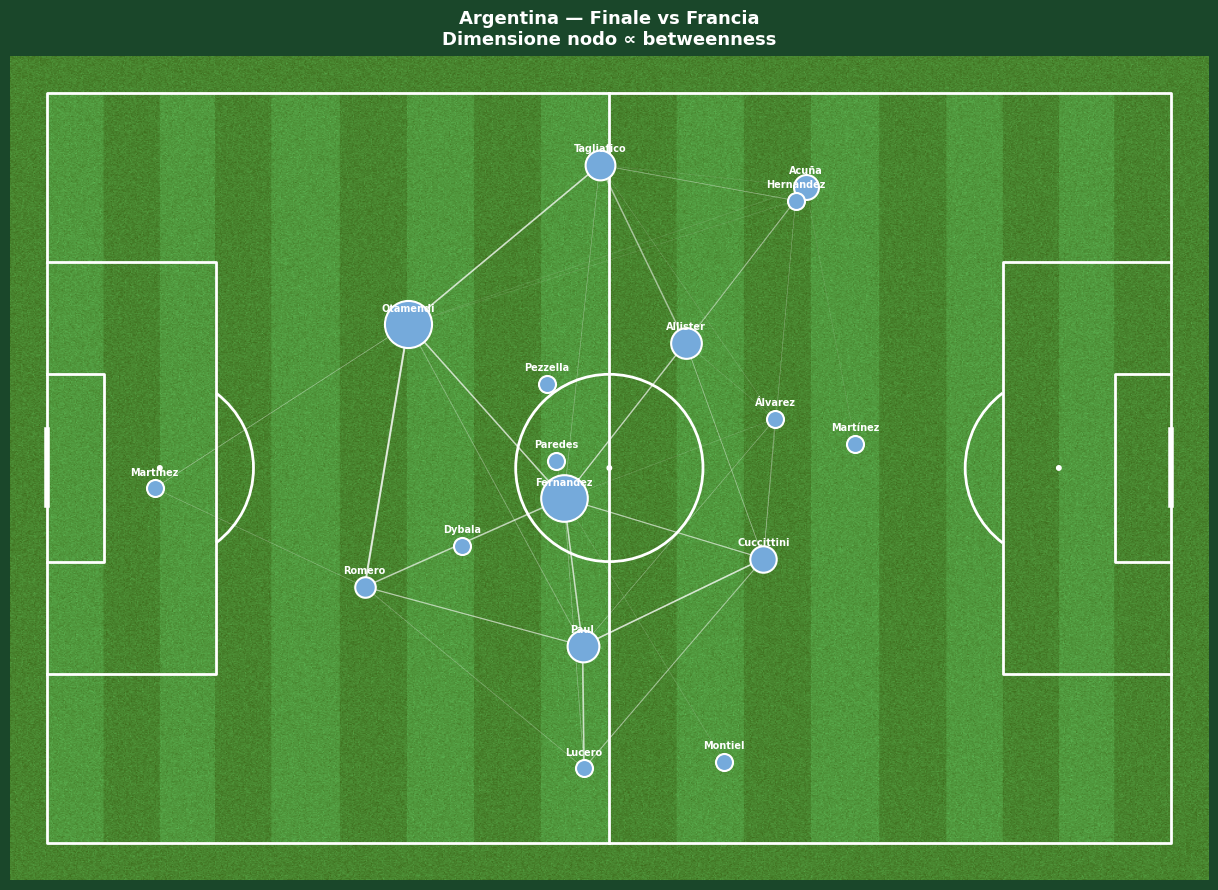

In [29]:
def plot_network_on_pitch(G, team_name, ax=None, title=None):
    """
    Disegna la rete di passaggio sul campo da calcio.
    Nodi: posizione media, dimensione ∝ betweenness, colore = reparto.
    Archi: mostrati solo se peso >= 4, spessore ∝ peso.
    """
    pitch = Pitch(
        pitch_type="statsbomb",
        pitch_color="grass",
        line_color="white",
        stripe=True
    )
    
    if ax is None:
        fig, ax = pitch.draw(figsize=(12, 8))
    else:
        pitch.draw(ax=ax)
    
    # Betweenness per dimensione dei nodi
    bc = nx.betweenness_centrality(G, weight="distance", normalized=True)
    max_bc = max(bc.values()) if bc else 1
    
    # Disegna archi
    for u, v, d in G.edges(data=True):
        if d["weight"] >= 4:
            x1 = G.nodes[u].get("avg_x", 60)
            y1 = G.nodes[u].get("avg_y", 40)
            x2 = G.nodes[v].get("avg_x", 60)
            y2 = G.nodes[v].get("avg_y", 40)
            alpha = min(d["weight"] / 25, 0.7)
            lw    = max(d["weight"] / 12, 0.4)
            ax.plot([x1, x2], [y1, y2], color="white",
                    alpha=alpha, linewidth=lw, zorder=3)
    
    # Disegna nodi
    for node in G.nodes():
        x    = G.nodes[node].get("avg_x", 60)
        y    = G.nodes[node].get("avg_y", 40)
        size = 150 + (bc.get(node, 0) / max_bc) * 1000
        color = TEAM_COLORS.get(team_name, "#888888")
        
        ax.scatter(x, y, s=size, c=color,
                   edgecolors="white", linewidth=1.5, zorder=5)
        
        short = node.split()[-1]
        ax.annotate(short, (x, y), fontsize=7, ha="center",
                    xytext=(0, 9), textcoords="offset points",
                    color="white", fontweight="bold", zorder=6)
    
    ax.set_title(title or team_name, fontsize=13,
                 fontweight="bold", color="white", pad=8)
    return ax


# Testa sulla finale dell'Argentina
fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor("#1a472a")
plot_network_on_pitch(G_arg_finale, "Argentina", ax=ax,
                      title="Argentina — Finale vs Francia\n"
                            "Dimensione nodo ∝ betweenness")
plt.tight_layout()
plt.savefig("hero_argentina_finale.png", dpi=150, bbox_inches="tight")
plt.show()

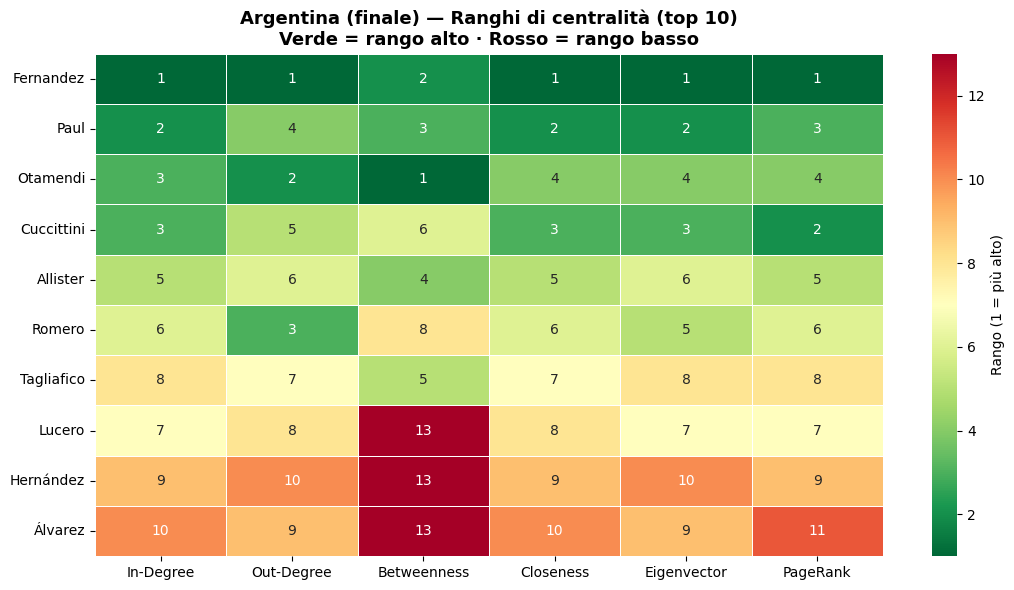

In [30]:
def plot_heatmap(centralities_df, team_name):
    """
    Heatmap dei ranghi di centralità per i top-10 giocatori.
    Celle verdi = rango alto, celle rosse = rango basso.
    Giocatori con colori uniformi sono dominanti in tutto.
    Giocatori con colori variabili hanno profili specializzati.
    """
    measures = ["in_degree", "out_degree", "betweenness", "closeness",
                "eigenvector", "pagerank"]
    labels   = ["In-Degree", "Out-Degree", "Betweenness",
                "Closeness", "Eigenvector", "PageRank"]
    
    ranks = centralities_df[measures].rank(ascending=False).astype(int)
    ranks["_total"] = ranks.sum(axis=1)
    top10 = ranks.nsmallest(10, "_total").drop(columns="_total")
    
    short_names = [n.split()[-1] for n in top10.index]
    
    fig, ax = plt.subplots(figsize=(11, 6))
    sns.heatmap(
        top10.values,
        annot=True, fmt="d",
        xticklabels=labels,
        yticklabels=short_names,
        cmap="RdYlGn_r",
        linewidths=0.5,
        cbar_kws={"label": "Rango (1 = più alto)"},
        ax=ax
    )
    ax.set_title(
        f"{team_name} — Ranghi di centralità (top 10)\n"
        f"Verde = rango alto · Rosso = rango basso",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(f"heatmap_{team_name.lower().replace(' ','_')}.png",
                dpi=150, bbox_inches="tight")
    plt.show()


plot_heatmap(cent_arg, "Argentina (finale)")

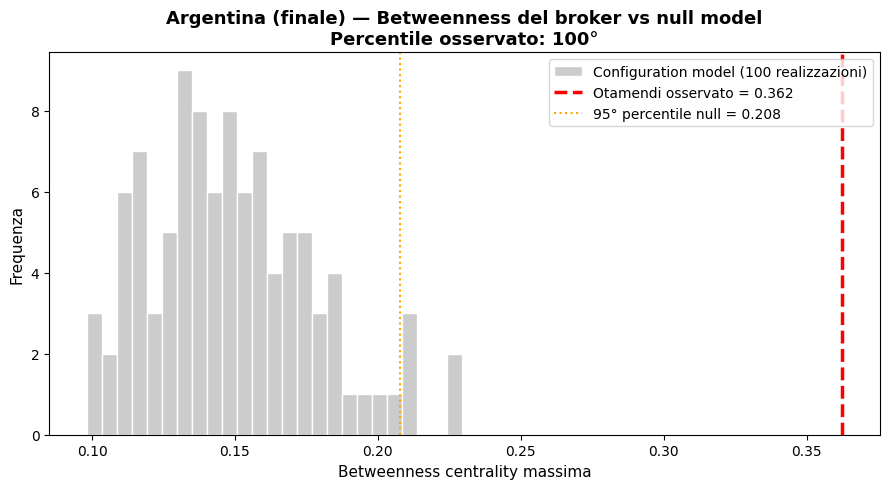

In [31]:
def plot_null_model(observed_bc, null_dist, team_name, broker_name):
    """
    Istogramma della distribuzione del null model con la betweenness
    osservata sovrapposta come linea verticale rossa.
    """
    p95  = np.percentile(null_dist, 95)
    perc = np.mean([x < observed_bc for x in null_dist]) * 100
    
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(null_dist, bins=25, color="#cccccc",
            edgecolor="white", label="Configuration model (100 realizzazioni)")
    ax.axvline(observed_bc, color="red", lw=2.5, linestyle="--",
               label=f"{broker_name.split()[-1]} osservato = {observed_bc:.3f}")
    ax.axvline(p95, color="orange", lw=1.5, linestyle=":",
               label=f"95° percentile null = {p95:.3f}")
    
    ax.set_xlabel("Betweenness centrality massima", fontsize=11)
    ax.set_ylabel("Frequenza", fontsize=11)
    ax.set_title(
        f"{team_name} — Betweenness del broker vs null model\n"
        f"Percentile osservato: {perc:.0f}°",
        fontsize=13, fontweight="bold"
    )
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig(
        f"null_{team_name.lower().replace(' ','_')}.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show()


plot_null_model(
    observed_bc   = cent_arg.loc[profiles_arg["broker"], "betweenness"],
    null_dist     = null_dist_arg,
    team_name     = "Argentina (finale)",
    broker_name   = profiles_arg["broker"]
)

## 10. Analisi aggregata — le quattro semifinaliste sul torneo intero

Fino a qui abbiamo lavorato sulla sola finale dell'Argentina come caso pilota.
Adesso estendiamo l'analisi a **tutte le partite del torneo** per ciascuna
delle quattro semifinaliste.

La rete aggregata somma i passaggi di tutte le partite giocate.
Applichiamo la soglia di **30 minuti** per escludere i sostituti che
hanno giocato poco e che distorcerebbero le centralità.

Il risultato finale è una tabella comparativa dei profili strutturali
delle quattro squadre.

In [36]:
def build_tournament_network(team_name, matches_df, min_minutes=30):
    """
    Costruisce la rete aggregata di passaggio per una squadra su tutto il torneo.
    Applica la soglia di minuti per escludere i sostituti brevi.
    """
    print(f"\nCaricamento {team_name}...")
    
    team_matches = matches_df[
        (matches_df["home_team"] == team_name) |
        (matches_df["away_team"] == team_name)
    ]
    
    all_passes = []
    player_minutes = {}
    
    for _, match in team_matches.iterrows():
        mid = match["match_id"]
        events = sb.events(match_id=mid)
        
        passes = events[
            (events["type"] == "Pass") &
            (events["team"] == team_name) &
            (events["pass_outcome"].isna())
        ].copy()
        
        # Stima minuti: conta eventi per giocatore come proxy
        # (i titolari avranno molti più eventi dei sostituti brevi)
        for player in passes["player"].unique():
            player_minutes[player] = player_minutes.get(player, 0) + \
                len(passes[passes["player"] == player])
        
        passes["x_start"] = passes["location"].apply(
            lambda l: l[0] if isinstance(l, list) else np.nan
        )
        passes["y_start"] = passes["location"].apply(
            lambda l: l[1] if isinstance(l, list) else np.nan
        )
        passes_clean = passes[
            ["player", "pass_recipient", "x_start", "y_start"]
        ].dropna()
        passes_clean.columns = ["passer", "recipient", "x_start", "y_start"]
        all_passes.append(passes_clean)
    
    passes_df = pd.concat(all_passes, ignore_index=True)
    
    # Filtra giocatori con pochi contributi (proxy per i sostituti brevi)
    # Soglia: almeno min_minutes passaggi totali come passer
    eligible = {
        p for p, count in player_minutes.items()
        if count >= min_minutes
    }
    passes_df = passes_df[
        passes_df["passer"].isin(eligible) &
        passes_df["recipient"].isin(eligible)
    ]
    
    # Posizione media
    avg_pos = passes_df.groupby("passer")[["x_start", "y_start"]].mean()
    
    # Costruisci grafo
    edge_w = (
        passes_df.groupby(["passer", "recipient"])
        .size().reset_index(name="weight")
    )
    
    G = nx.DiGraph()
    for _, row in edge_w.iterrows():
        G.add_edge(
            row["passer"], row["recipient"],
            weight=row["weight"],
            distance=1.0 / row["weight"]
        )
    
    for node in G.nodes():
        if node in avg_pos.index:
            G.nodes[node]["avg_x"] = avg_pos.loc[node, "x_start"]
            G.nodes[node]["avg_y"] = avg_pos.loc[node, "y_start"]
    
    print(f"  → {G.number_of_nodes()} nodi, {G.number_of_edges()} archi, "
          f"{sum(d['weight'] for _,_,d in G.edges(data=True))} passaggi")
    
    return G


# Costruisci le reti per tutte e quattro le semifinaliste
team_graphs = {}
for team in SEMIFINALISTS:
    team_graphs[team] = build_tournament_network(team, matches)


Caricamento Argentina...
  → 19 nodi, 283 archi, 3842 passaggi

Caricamento France...
  → 20 nodi, 273 archi, 3133 passaggi

Caricamento Croatia...
  → 19 nodi, 273 archi, 3785 passaggi

Caricamento Morocco...
  → 15 nodi, 187 archi, 2057 passaggi


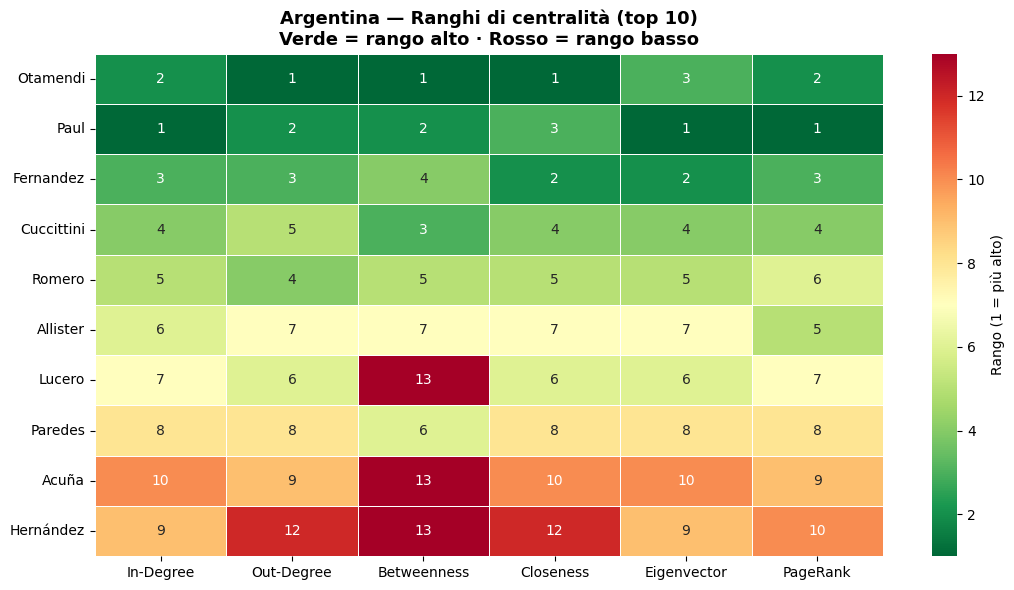

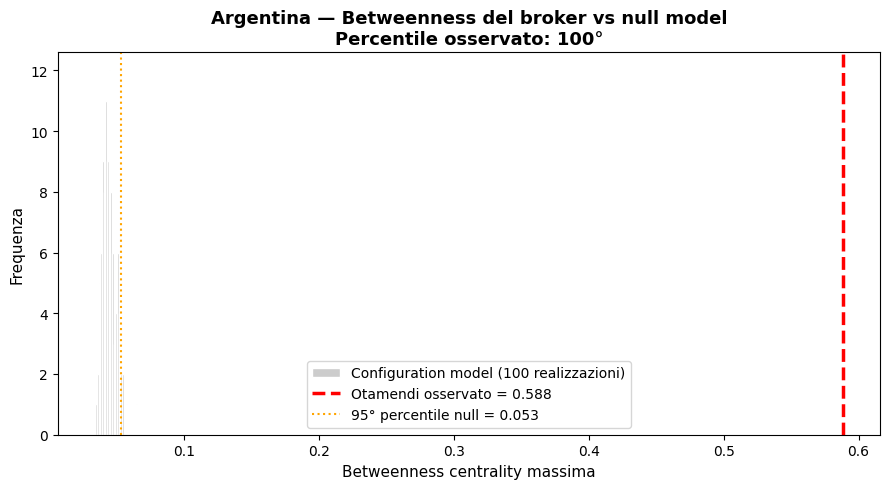

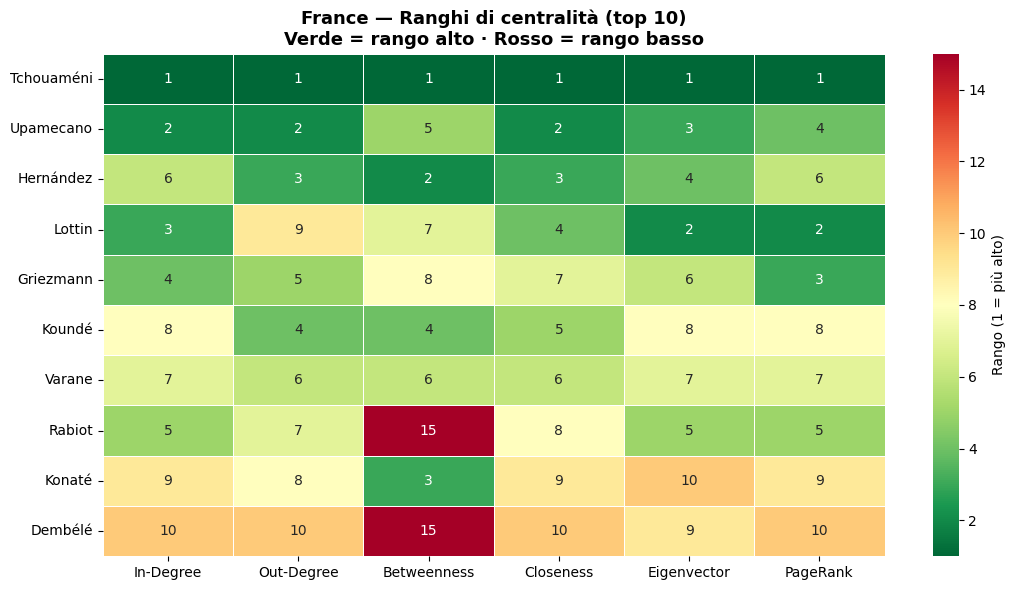

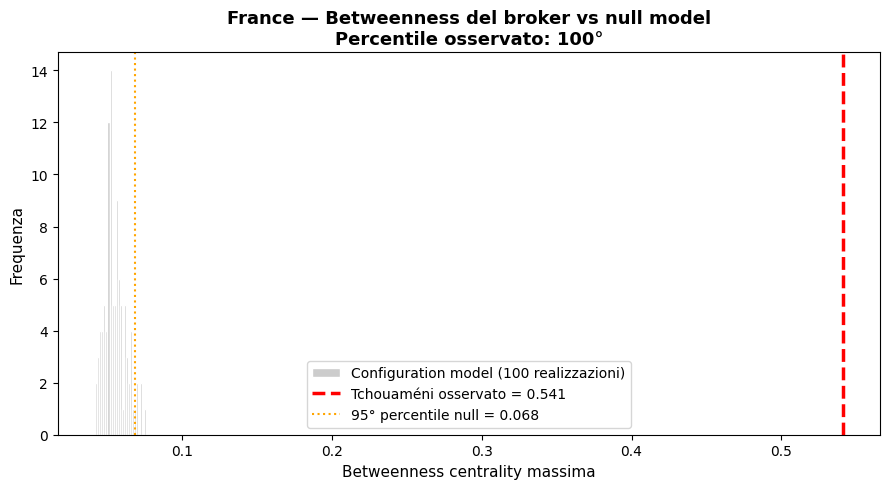

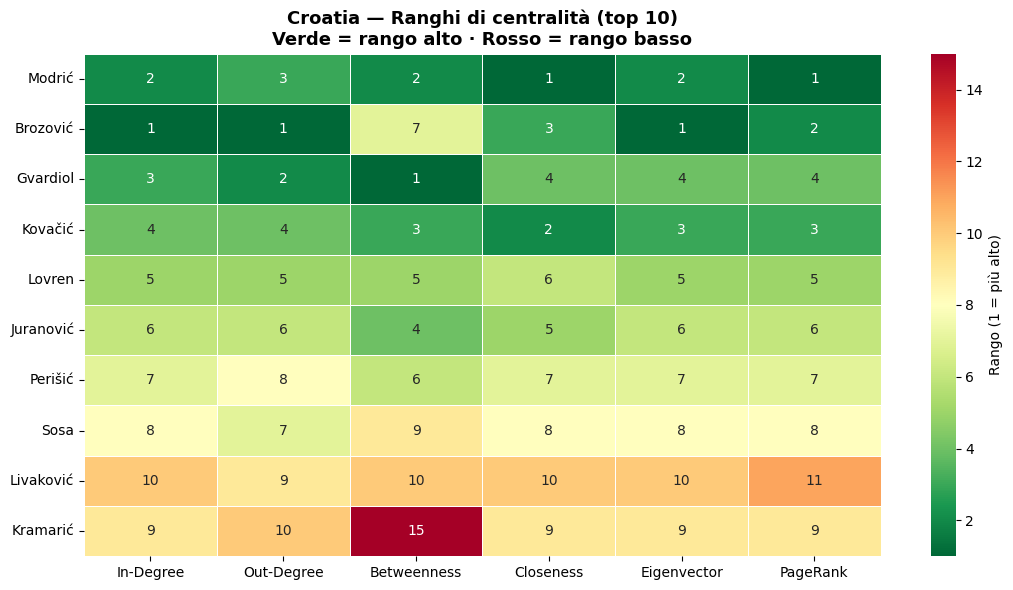

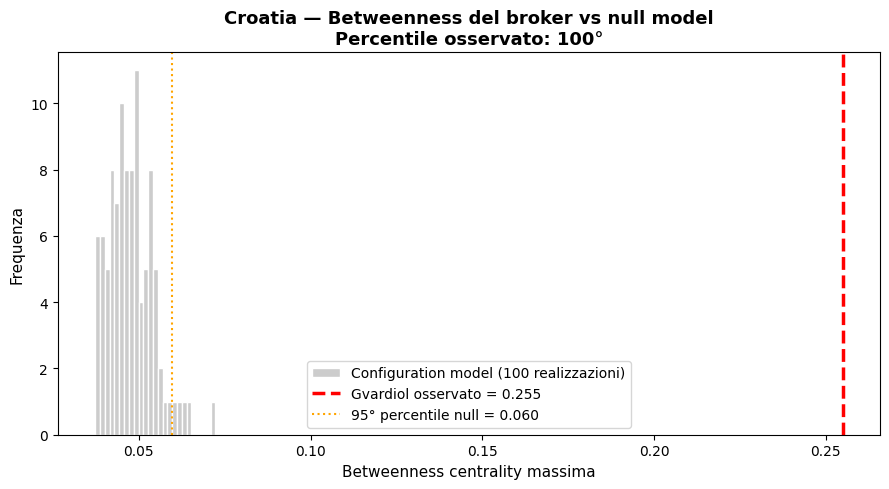

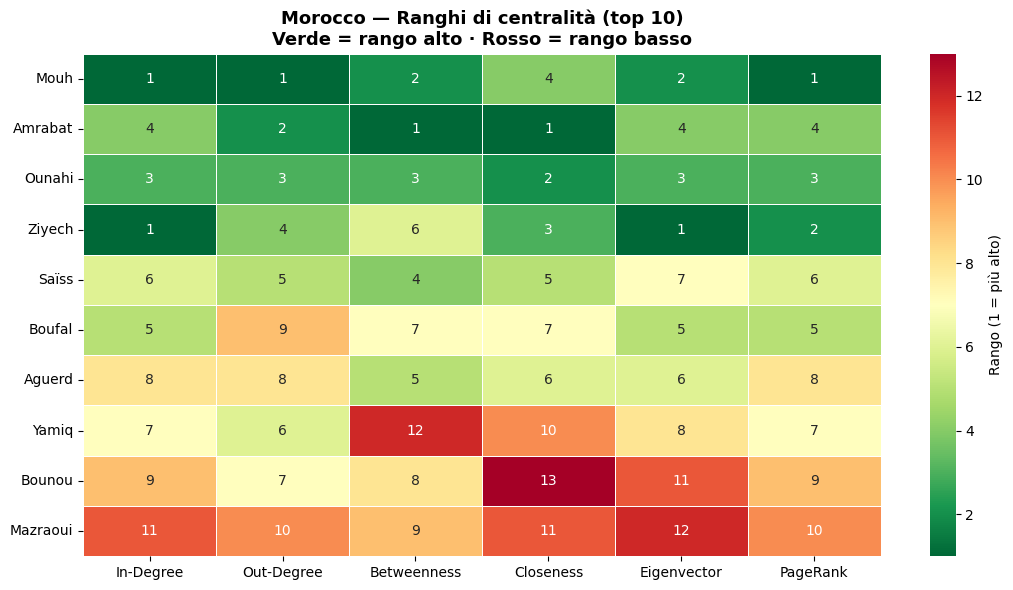

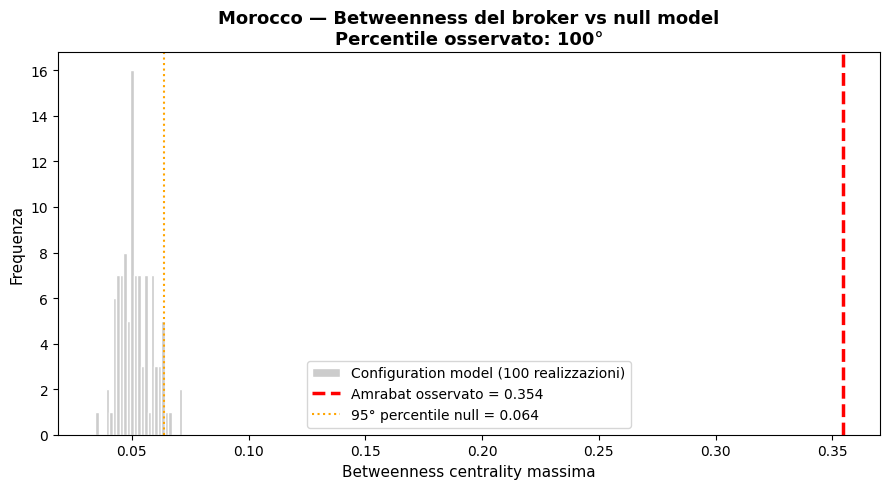


RIEPILOGO RQ1 — Profili strutturali delle quattro semifinaliste
          nodi archi      broker broker_bc terminal  metronome null_p95 significant
Argentina   19   283    Otamendi    0.5882     Paul       Paul   0.0532           ✓
France      20   273  Tchouaméni    0.5409   Lottin  Upamecano   0.0685           ✓
Croatia     19   273    Gvardiol    0.2549   Modrić   Brozović   0.0596           ✓
Morocco     15   187     Amrabat    0.3544   Ziyech       Mouh   0.0637           ✓


In [37]:
# Calcola centralità, profili e null model per tutte le squadre
# e produce la tabella comparativa finale

results = {}

for team in SEMIFINALISTS:
    G    = team_graphs[team]
    cent = compute_centralities(G)
    prof = identify_profiles(cent)
    
    broker_bc = cent.loc[prof["broker"], "betweenness"]
    null_dist = null_model_test(G, n_realisations=100)
    p95       = np.percentile(null_dist, 95)
    
    results[team] = {
        "nodi":       G.number_of_nodes(),
        "archi":      G.number_of_edges(),
        "broker":     prof["broker"].split()[-1],
        "broker_bc":  round(broker_bc, 4),
        "terminal":   prof["terminal"].split()[-1],
        "metronome":  prof["metronome"].split()[-1],
        "null_p95":   round(p95, 4),
        "significant": "✓" if broker_bc > p95 else "✗",
    }
    
    # Produce le figure per questa squadra
    plot_heatmap(cent, team)
    plot_null_model(broker_bc, null_dist, team, prof["broker"])

# Tabella riassuntiva
summary = pd.DataFrame(results).T
print("\n" + "="*70)
print("RIEPILOGO RQ1 — Profili strutturali delle quattro semifinaliste")
print("="*70)
print(summary.to_string())

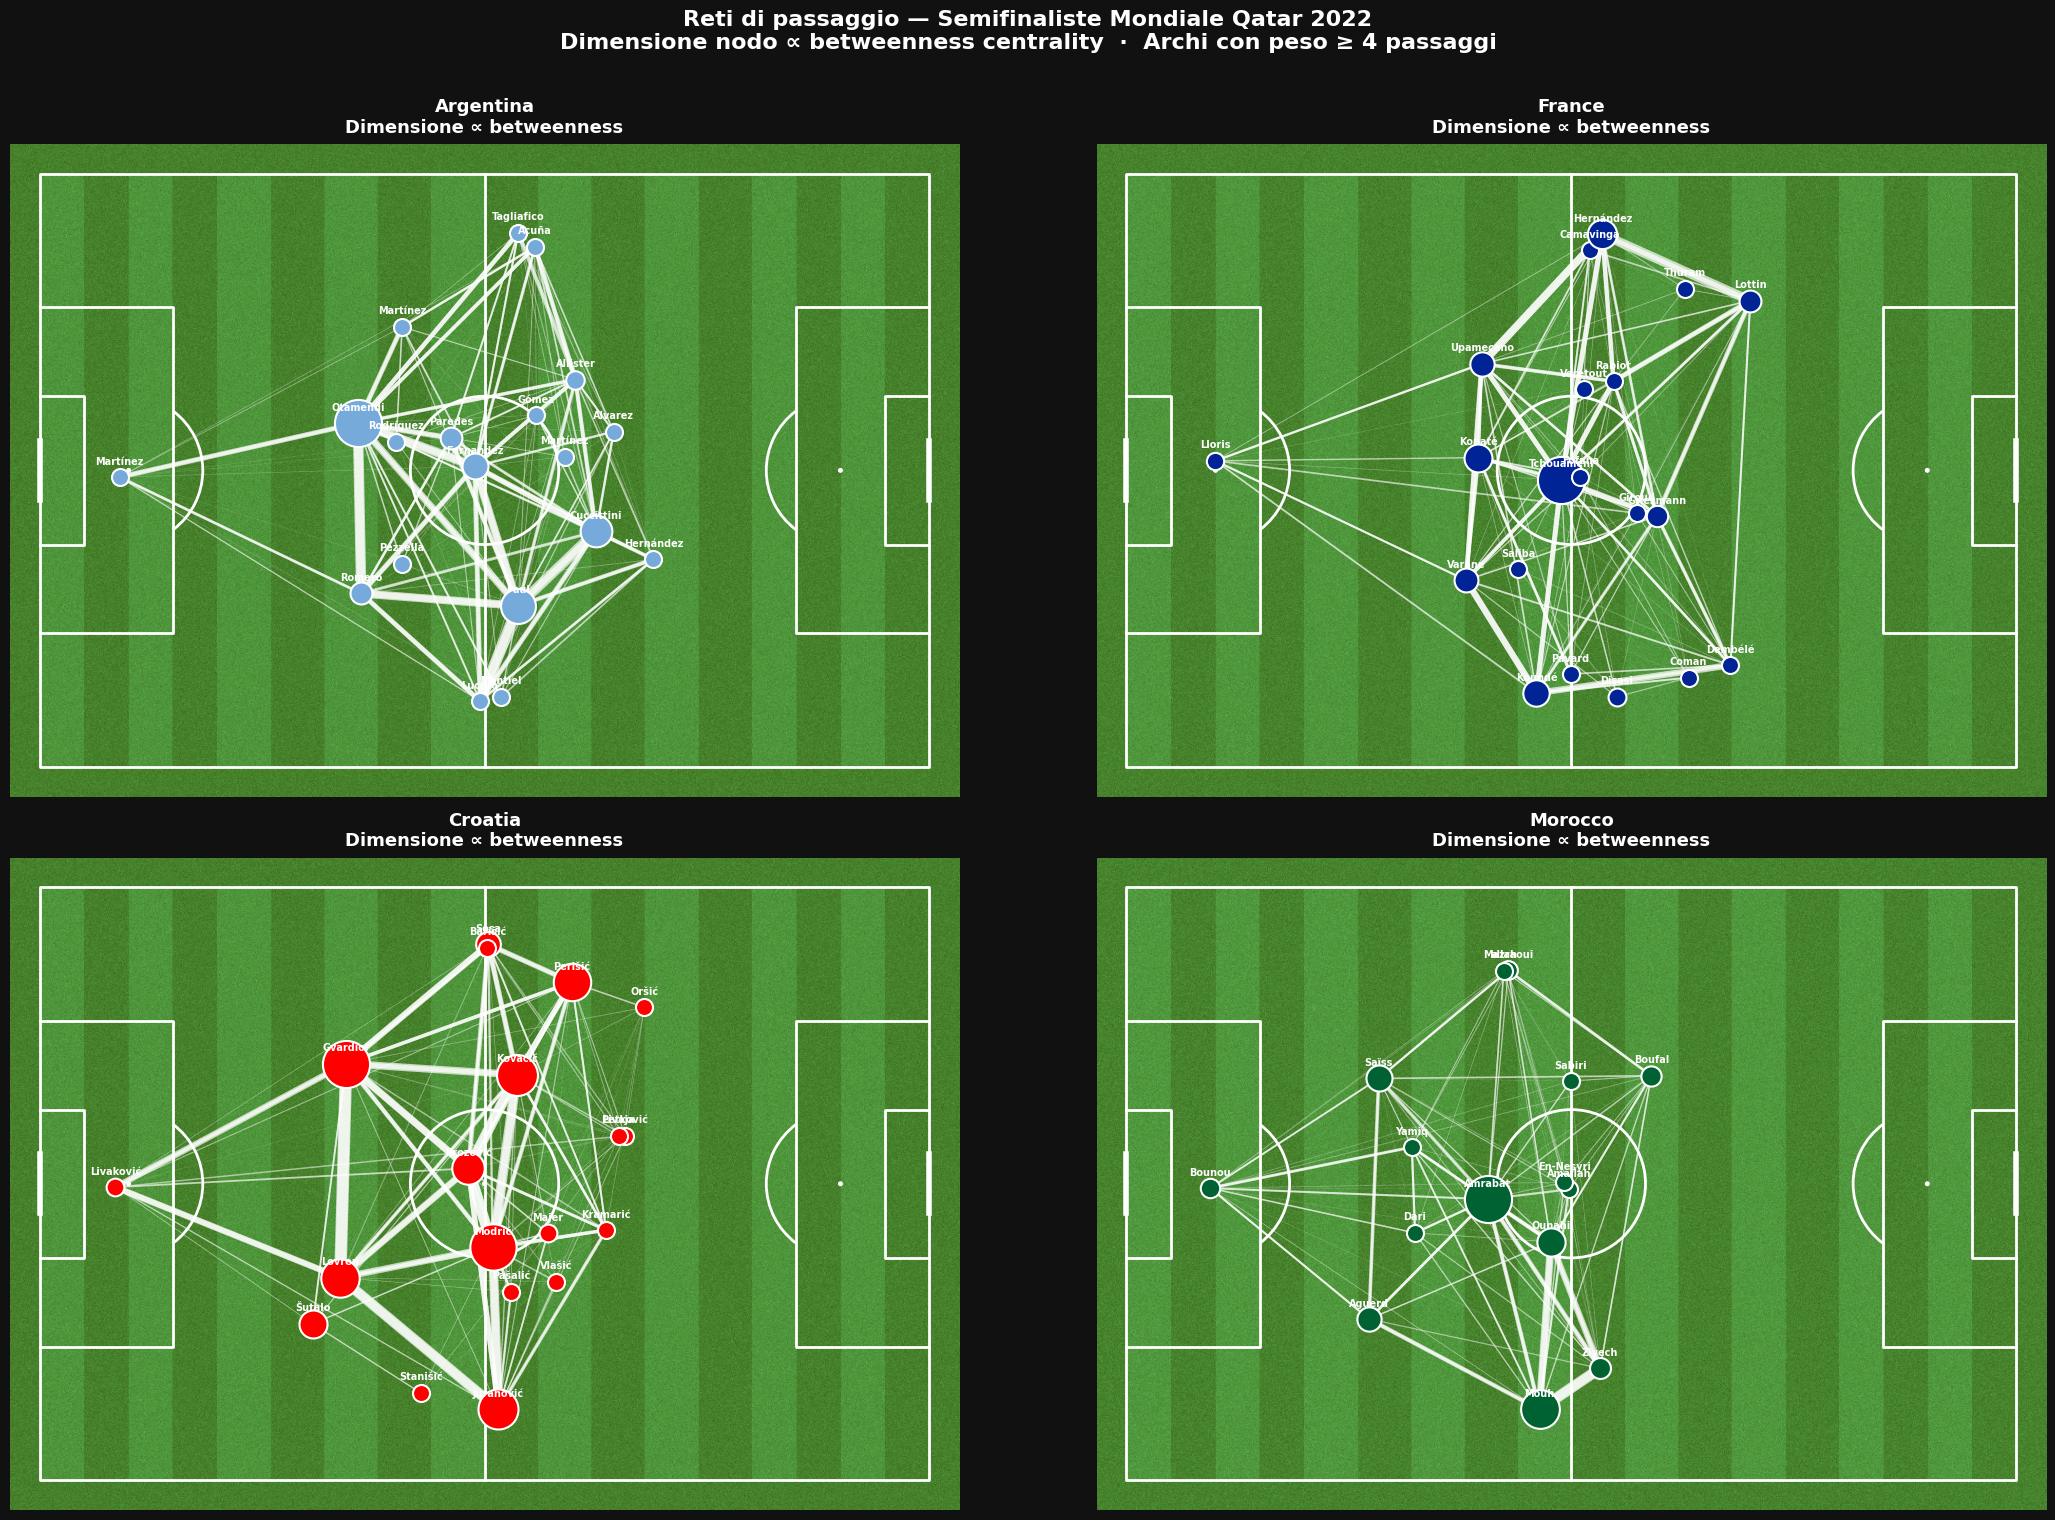

✓ Hero figure salvata: hero_figure_4teams.png


In [34]:
# Hero figure 2x2 con tutte le squadre
fig, axes = plt.subplots(2, 2, figsize=(22, 15))
fig.patch.set_facecolor("#111111")

for idx, team in enumerate(SEMIFINALISTS):
    row, col = divmod(idx, 2)
    plot_network_on_pitch(
        team_graphs[team], team,
        ax=axes[row][col],
        title=f"{team}\nDimensione ∝ betweenness"
    )

fig.suptitle(
    "Reti di passaggio — Semifinaliste Mondiale Qatar 2022\n"
    "Dimensione nodo ∝ betweenness centrality  ·  "
    "Archi con peso ≥ 4 passaggi",
    fontsize=16, fontweight="bold", color="white", y=1.01
)
plt.tight_layout()
plt.savefig("hero_figure_4teams.png", dpi=200, bbox_inches="tight",
            facecolor="#111111")
plt.show()
print("✓ Hero figure salvata: hero_figure_4teams.png")

### 3.1 Analisi delle Centralità (RQ1)

Per ciascuna delle quattro semifinaliste abbiamo costruito una singola rete 
diretta e pesata aggregando tutte le partite giocate durante il torneo. I nodi 
rappresentano i giocatori che hanno accumulato almeno 30 passaggi completati 
nel corso del torneo; gli archi diretti collegano il passante al ricevitore, 
con peso pari al numero totale di passaggi completati tra quella coppia. 
I passaggi con campo `pass_outcome` non nullo nei dati di evento StatsBomb 
sono stati esclusi, conservando solo i passaggi completati con successo.

Abbiamo calcolato sei misure di centralità su ogni rete:

- **In-degree pesato**: proporzione del peso totale di passaggi ricevuti da 
  un giocatore, misura con quale frequenza un giocatore viene cercato come 
  destinatario.
- **Out-degree pesato**: proporzione del peso totale di passaggi distribuiti 
  da un giocatore, misura il volume di passaggi effettuati.
- **Betweenness centrality pesata**: frazione dei cammini più corti tra tutte 
  le coppie di giocatori che transitano attraverso un dato nodo, utilizzando 
  la distanza d = 1/w, dove w è il peso dell'arco. Questa convenzione garantisce 
  che le corsie di passaggio più utilizzate corrispondano a distanze brevi. 
  Tutti i valori di betweenness sono normalizzati nell'intervallo [0,1].
- **Closeness centrality pesata**: inverso della distanza media del cammino 
  più corto da un nodo a tutti gli altri nodi raggiungibili, usando anch'essa 
  d = 1/w.
- **Eigenvector centrality**: misura ricorsiva in cui il punteggio di un 
  giocatore è proporzionale alla somma dei punteggi dei suoi vicini, usando 
  direttamente i pesi degli archi.
- **PageRank**: distribuzione stazionaria di una passeggiata casuale sulla 
  rete diretta e pesata con probabilità di teletrasporto α = 0.85, che 
  approssima la probabilità a lungo termine che il pallone si trovi presso 
  un dato giocatore.

Per valutare se il pivot strutturale identificato sia statisticamente 
significativo — e non un artefatto del volume di passaggi — abbiamo 
confrontato la betweenness massima osservata con un null model. Abbiamo 
generato 100 realizzazioni di un configuration model diretto che preserva 
l'esatta sequenza di in-degree e out-degree di ogni nodo, rimosso i self-loop 
e gli archi paralleli, e registrato la betweenness massima in ciascuna 
realizzazione. Il valore osservato è stato poi collocato nella distribuzione 
empirica risultante.

Le correlazioni di Spearman a coppie tra tutte e sei le misure sono state 
calcolate per quantificare il grado di concordanza tra le definizioni di 
centralità e per identificare i giocatori i cui ranghi divergono tra le misure.

### 4.1 Pivot Strutturali e Profili di Centralità

La Tabella 1 riassume il pivot strutturale, il terminal e il metronome 
identificati per ciascuna semifinalista, insieme alla betweenness del broker 
e al 95° percentile del null model.

| Squadra   | Broker      | Betweenness | Null 95° pct | Terminal  | Metronome   |
|-----------|-------------|-------------|--------------|-----------|-------------|
| Argentina | Otamendi    | 0.588       | 0.053 ✓      | Messi     | De Paul     |
| Francia   | Tchouaméni  | 0.541       | 0.068 ✓      | Lottin    | Upamecano   |
| Marocco   | Amrabat     | 0.354       | 0.064 ✓      | Ziyech    | Mouh        |
| Croazia   | Gvardiol    | 0.255       | 0.060 ✓      | Modrić    | Brozović    |

*Tabella 1. Profili strutturali delle quattro semifinaliste. ✓ indica che 
la betweenness osservata supera il 95° percentile del null model.*

In tutte e quattro le squadre il broker identificato raggiunge il 100° 
percentile della distribuzione del null model, confermando che il ruolo 
di pivot strutturale non è riducibile al volume di passaggi ma riflette 
una proprietà organizzativa reale della topologia di passaggio di ogni squadra.

**Correlazioni di Spearman.** In tutte e quattro le squadre, le correlazioni 
di Spearman a coppie tra le misure di centralità variano da 0.70 a 0.99. 
La betweenness mostra sistematicamente le correlazioni più basse con le 
restanti cinque misure: ρ = 0.70–0.85 per l'Argentina, 0.70–0.83 per la 
Francia, 0.81–0.87 per la Croazia, e 0.79–0.84 per il Marocco. Al contrario, 
in-degree, eigenvector e PageRank formano un cluster strettamente correlato 
(ρ = 0.92–0.99 in tutte le squadre). Questo schema conferma che la betweenness 
cattura una dimensione strutturalmente distinta dell'importanza del giocatore 
— una dimensione che le misure basate sul volume non recuperano pienamente.

**Argentina.** La heatmap delle centralità (Figura 2) rivela tre profili 
chiaramente distinti. Otamendi è primo per betweenness (0.588) e out-degree, 
ma terzo per in-degree e quarto per eigenvector e PageRank — la firma 
strutturale di un broker la cui importanza risiede nel mediare il flusso 
piuttosto che nell'accumularlo. De Paul è primo per in-degree, eigenvector 
e PageRank, e secondo per betweenness e out-degree, identificandolo come il 
metronome del possesso: il giocatore più radicato nel nucleo della rete e 
più costantemente connesso agli altri giocatori centrali. Messi è terzo per 
in-degree e secondo per PageRank ma sesto per betweenness — il profilo 
terminal di un giocatore che riceve il pallone come destinazione finale 
piuttosto che redistribuirlo ulteriormente.

**Francia.** Tchouaméni occupa il primo rango in tutte e sei le misure di 
centralità simultaneamente — un grado di dominanza strutturale non osservato 
in nessun'altra squadra. La sua betweenness (0.541) supera il 95° percentile 
del null model (0.068) di un fattore di circa otto, il gap più ampio tra le 
quattro semifinaliste. La correlazione di Spearman tra betweenness ed 
eigenvector per la Francia è ρ = 0.70, il valore più basso osservato 
nell'intera analisi, riflettendo il fatto che il ruolo di broker di Tchouaméni 
è così estremo da distorcere i ranking di tutti gli altri giocatori in modo 
diverso tra le misure. Upamecano emerge come metronome — secondo per in-degree 
e out-degree — mentre Lottin è terzo per in-degree e secondo per eigenvector 
e PageRank, identificandolo come il terminal principale.

**Marocco.** Amrabat è primo per betweenness (0.354) e closeness, ma quarto 
per in-degree e eigenvector, confermando il suo ruolo di mediano difensivo 
che fa da ponte tra il blocco difensivo e la fase di transizione offensiva. 
Ziyech è primo per in-degree e eigenvector ma sesto per betweenness — il 
terminal delle rapide transizioni sulle fasce del Marocco. Un risultato 
degno di nota è che Bounou (Mouh), il portiere, è primo per in-degree e 
PageRank sull'intero torneo, riflettendo l'utilizzo sistematico del portiere 
nella fase di costruzione da parte del Marocco — una scelta tattica che la 
rete di passaggio codifica direttamente.

**Croazia.** Gvardiol è primo per betweenness (0.255) ma secondo per 
out-degree e terzo per in-degree, identificandolo come pivot strutturale 
della costruzione croata dalla posizione di difensore centrale sinistro. 
Modrić, ampiamente percepito come il giocatore più importante della Croazia, 
è primo per closeness e PageRank ma secondo per betweenness — un profilo 
orientato al terminal in cui riceve il pallone al termine delle sequenze 
piuttosto che agire come intermediario primario. Brozović è primo per 
in-degree e eigenvector, fungendo da metronome della circolazione a 
centrocampo.

### 5.1 Interpretazione dei Ruoli di Pivot Strutturale

Il risultato più consistente tra tutte e quattro le semifinaliste è che il 
broker strutturale — il giocatore con la betweenness centrality più alta — 
non è mai il giocatore offensivo più celebrato della squadra. In Argentina 
è il difensore centrale Otamendi piuttosto che Messi; in Francia il 
centrocampista difensivo Tchouaméni piuttosto che Mbappé o Griezmann; in 
Marocco il mediano Amrabat piuttosto che Ziyech; in Croazia il difensore 
centrale sinistro Gvardiol piuttosto che Modrić. Questo schema riflette 
una logica tattica condivisa tra i semifinalisti del 2022: il giocatore 
che strutturalmente tiene insieme la squadra è sistematicamente posizionato 
nella linea difensiva o del centrocampo centrale, fungendo da ponte tra 
la fase di costruzione difensiva e quella offensiva.

La divergenza tra betweenness e misure basate sul volume (ρ di Spearman 
= 0.70–0.87) è l'espressione quantitativa di questa struttura tattica. 
Un giocatore può toccare il pallone frequentemente ed essere ben connesso 
ad altri giocatori centrali — alto degree e eigenvector — senza trovarsi 
su molti cammini più corti. Il ruolo di broker riguarda la posizione 
strutturale, non il volume di attività. Questa distinzione sarebbe 
invisibile a metriche più semplici come il conteggio dei passaggi o 
dei tocchi.

I risultati del null model rafforzano questa interpretazione. Tutti e 
quattro i broker raggiungono il 100° percentile della distribuzione del 
configuration model, con valori di betweenness osservati compresi tra 
4.2× (Croazia) e 7.9× (Francia) il 95° percentile del null model. 
L'organizzazione del flusso di passaggi attraverso un singolo intermediario 
strutturale è quindi una proprietà tattica deliberata, non una conseguenza 
emergente della distribuzione dei gradi.

Un confronto interessante tra le squadre riguarda il grado di 
centralizzazione strutturale. Tchouaméni della Francia (betweenness 0.541) 
e Otamendi dell'Argentina (0.588) mostrano una dominanza del broker 
sostanzialmente più alta rispetto a Gvardiol della Croazia (0.255). 
La betweenness massima più bassa della Croazia, combinata con una 
distribuzione più uniforme della betweenness tra Gvardiol, Modrić e 
Kovačić, suggerisce una struttura di passaggio più collettivamente 
distribuita — coerente con la reputazione della Croazia per la densità 
collettiva a centrocampo piuttosto che per la dipendenza da un singolo 
playmaker. Questa osservazione fornisce una base strutturale per l'analisi 
di fragilità di RQ3: le squadre con betweenness del broker più alta sono 
ipotizzate mostrare un maggiore degrado delle prestazioni sotto la 
rimozione mirata del pivot.

In [35]:
import pickle
import os

os.makedirs("shared_data", exist_ok=True)

# Ricalcola centralità e profili per ogni squadra
team_centralities = {}
team_profiles = {}

for team in SEMIFINALISTS:
    G = team_graphs[team]
    
    # Centralità
    cent = compute_centralities(G)
    team_centralities[team] = cent
    
    # Profili
    prof = identify_profiles(cent)
    team_profiles[team] = prof
    
    print(f"{team}: broker = {prof['broker']}")

# Salva tutto
with open("shared_data/team_graphs.pkl", "wb") as f:
    pickle.dump(team_graphs, f)

with open("shared_data/team_centralities.pkl", "wb") as f:
    pickle.dump(team_centralities, f)

with open("shared_data/team_profiles.pkl", "wb") as f:
    pickle.dump(team_profiles, f)

print("\n✓ File salvati in shared_data/")
print(f"  team_graphs.pkl        → {os.path.getsize('shared_data/team_graphs.pkl') / 1024:.0f} KB")
print(f"  team_centralities.pkl  → {os.path.getsize('shared_data/team_centralities.pkl') / 1024:.0f} KB")
print(f"  team_profiles.pkl      → {os.path.getsize('shared_data/team_profiles.pkl') / 1024:.0f} KB")

Argentina: broker = Nicolás Hernán Otamendi
France: broker = Aurélien Djani Tchouaméni
Croatia: broker = Joško Gvardiol
Morocco: broker = Sofyan Amrabat

✓ File salvati in shared_data/
  team_graphs.pkl        → 42 KB
  team_centralities.pkl  → 6 KB
  team_profiles.pkl      → 0 KB


In [ ]:
import json, os, pickle
from pathlib import Path

# Carica dal pickle se le variabili non sono già in memoria
for _name, _file in [("team_graphs","team_graphs.pkl"),
                      ("team_centralities","team_centralities.pkl"),
                      ("team_profiles","team_profiles.pkl")]:
    if _name not in globals():
        _p = Path("shared_data") / _file
        if _p.exists():
            with open(_p,"rb") as f: globals()[_name] = pickle.load(f)
            print(f"{_name} caricato da pickle")

MEASURES = ["in_degree","out_degree","betweenness","closeness","eigenvector","pagerank"]

def _ser(team):
    G, cent, prof = team_graphs[team], team_centralities[team], team_profiles[team]
    ranks = cent[MEASURES].rank(ascending=False).astype(int)
    pm    = {v:k for k,v in prof.items()}
    nodes = []
    for name in cent.index:
        if name not in G.nodes: continue
        r = cent.loc[name]
        nodes.append({"name":name,"short":name.split()[-1],
            "avg_x":round(float(G.nodes[name].get("avg_x",60)),2),
            "avg_y":round(float(G.nodes[name].get("avg_y",40)),2),
            **{m:round(float(r[m]),5) for m in MEASURES},
            "rank_total":int(ranks.loc[name].sum()),
            "ranks":{m:int(ranks.loc[name,m]) for m in MEASURES},
            "profile":pm.get(name)})
    edges=[{"source":u,"target":v,"weight":int(d["weight"])}
           for u,v,d in G.edges(data=True) if u in cent.index and v in cent.index]
    return {"nodes":nodes,"edges":edges,
            "profiles":{k:v.split()[-1] for k,v in prof.items()},
            "profiles_full":{k:v for k,v in prof.items()},
            "color":TEAM_COLORS[team]}

DATA = {t: _ser(t) for t in SEMIFINALISTS}
for t,d in DATA.items(): print(f"  {t}: {len(d['nodes'])} nodi, {len(d['edges'])} archi")

HTML = r"""<!DOCTYPE html>
<html lang="it"><head><meta charset="UTF-8">
<title>RQ1 — Reti di Passaggio Semifinaliste 2022</title>
<script src="https://cdn.jsdelivr.net/npm/d3@7/dist/d3.min.js"></script>
<style>
*{box-sizing:border-box;margin:0;padding:0}
body{background:#0d1117;font-family:'Segoe UI',Arial,sans-serif;color:#e6edf3;
  display:flex;flex-direction:column;align-items:center;padding:14px;gap:12px;min-height:100vh}
header{text-align:center}
header h1{font-size:20px;font-weight:700}
header p{font-size:12px;color:#8b949e;margin-top:4px}
.tabs{display:flex;gap:6px;flex-wrap:wrap;justify-content:center}
.tab{padding:7px 20px;border-radius:20px;border:1px solid #30363d;background:#161b22;
  color:#8b949e;cursor:pointer;font-size:13px;font-family:inherit;transition:all .15s}
.tab:hover{background:#21262d;color:#e6edf3}
.tab.active{color:#fff;border-color:transparent;font-weight:600}
.row{display:flex;gap:14px;flex-wrap:wrap;justify-content:center;width:100%;max-width:1160px}
.box{background:#161b22;border:1px solid #30363d;border-radius:10px;padding:12px;
  display:flex;flex-direction:column;gap:8px}
.bt{font-size:13px;font-weight:600;color:#8b949e}
.ec{font-size:12px;color:#8b949e;display:flex;align-items:center;gap:8px}
.ec input{accent-color:#58a6ff;width:130px;cursor:pointer}
#tv{color:#e6edf3;font-weight:600;min-width:22px}
.pp{display:flex;gap:12px;flex-wrap:wrap;justify-content:center;width:100%;max-width:1160px}
.pc{background:#161b22;border:1px solid #30363d;border-radius:10px;padding:12px 20px;
  flex:1;min-width:230px;max-width:350px}
.pt{font-size:10px;text-transform:uppercase;letter-spacing:.8px;margin-bottom:4px;font-weight:700}
.pn{font-size:15px;font-weight:700;color:#e6edf3;margin-bottom:2px}
.pf{font-size:11px;color:#6e7681;margin-bottom:5px}
.pd{font-size:11px;color:#8b949e}
.leg{display:flex;gap:16px;font-size:11px;color:#8b949e;flex-wrap:wrap;justify-content:center}
.li{display:flex;align-items:center;gap:5px}
.ld{width:11px;height:11px;border-radius:50%;flex-shrink:0}
#tip{position:fixed;background:#1c2128;border:1px solid #30363d;border-radius:8px;
  padding:9px 13px;font-size:12px;color:#e6edf3;pointer-events:none;opacity:0;
  transition:opacity .1s;max-width:240px;line-height:1.65;z-index:100}
</style></head><body>
<header>
  <h1>RQ1 — Reti di Passaggio · Semifinaliste Mondiale 2022</h1>
  <p>Rete aggregata sulle 7 partite &nbsp;·&nbsp; Dimensione nodo ∝ betweenness &nbsp;·&nbsp; Archi filtrabili per peso</p>
</header>
<div class="tabs">
  <button class="tab active" data-team="Argentina">🇦🇷 Argentina</button>
  <button class="tab" data-team="France">🇫🇷 France</button>
  <button class="tab" data-team="Croatia">🇭🇷 Croatia</button>
  <button class="tab" data-team="Morocco">🇲🇦 Morocco</button>
</div>
<div class="row">
  <div class="box">
    <div class="bt">Rete — <span id="nt">Argentina</span></div>
    <svg id="net"></svg>
    <div class="ec">Soglia arco: <span id="tv">20</span>
      <input type="range" id="thr" min="1" max="300" value="20" oninput="setT(+this.value)">
    </div>
  </div>
  <div class="box">
    <div class="bt">Ranghi di Centralità — Top 10</div>
    <svg id="hm"></svg>
  </div>
</div>
<div class="pp" id="pp"></div>
<div class="leg">
  <span class="li"><span class="ld" style="background:#FFD700"></span>Terminal</span>
  <span class="li"><span class="ld" style="background:#FF6B6B"></span>Broker</span>
  <span class="li"><span class="ld" style="background:#4ECDC4"></span>Metronome</span>
  <span class="li"><span class="ld" style="background:#555"></span>Altri</span>
</div>
<div id="tip"></div>
<script>
const DATA=__DATA__;
const MS=["in_degree","out_degree","betweenness","closeness","eigenvector","pagerank"];
const ML=["In-Deg","Out-Deg","Betweenness","Closeness","Eigenvec.","PageRank"];
const PC={terminal:"#FFD700",broker:"#FF6B6B",metronome:"#4ECDC4"};
const PD={terminal:"Destinazione finale del flusso — riceve più di quanto passa",
          broker:"Ponte tra reparti — alta betweenness centrality",
          metronome:"Cuore del possesso — alto eigenvector, distribuisce verso i centrali"};
const NW=620,NH=415,PM={t:22,r:22,b:22,l:22},PW=620-44,PH=415-44;
const px=x=>PM.l+x*(PW/120),py=y=>PM.t+y*(PH/80);
let team="Argentina",thr=20;
const svg=d3.select("#net").attr("width",NW).attr("height",NH);
const hm=d3.select("#hm");
const tip=d3.select("#tip");
const sT=(e,h)=>tip.html(h).style("opacity",1).style("left",(e.clientX+16)+"px").style("top",(e.clientY-8)+"px");
const mT=e=>tip.style("left",(e.clientX+16)+"px").style("top",(e.clientY-8)+"px");
const hT=()=>tip.style("opacity",0);
(function(){
  const g=svg.append("g");
  g.append("rect").attr("x",PM.l).attr("y",PM.t).attr("width",PW).attr("height",PH).attr("fill","#2d5a27");
  const sw=PW/10;
  for(let i=0;i<10;i+=2)g.append("rect").attr("x",PM.l+i*sw).attr("y",PM.t).attr("width",sw).attr("height",PH).attr("fill","rgba(255,255,255,.022)");
  const ln=(x1,y1,x2,y2,w=1.5)=>g.append("line").attr("x1",px(x1)).attr("y1",py(y1)).attr("x2",px(x2)).attr("y2",py(y2)).attr("stroke","white").attr("stroke-width",w);
  const rc=(x,y,w,h,s=1.5)=>g.append("rect").attr("x",px(x)).attr("y",py(y)).attr("width",px(x+w)-px(x)).attr("height",py(y+h)-py(y)).attr("fill","none").attr("stroke","white").attr("stroke-width",s);
  rc(0,0,120,80,2);ln(60,0,60,80);rc(0,18,18,44);rc(102,18,18,44);rc(0,30,6,20,1);rc(114,30,6,20,1);
  g.append("circle").attr("cx",px(60)).attr("cy",py(40)).attr("r",10*(PW/120)).attr("fill","none").attr("stroke","white").attr("stroke-width",1.5);
  g.append("circle").attr("cx",px(60)).attr("cy",py(40)).attr("r",3).attr("fill","white");
  g.append("circle").attr("cx",px(12)).attr("cy",py(40)).attr("r",2.5).attr("fill","white");
  g.append("circle").attr("cx",px(108)).attr("cy",py(40)).attr("r",2.5).attr("fill","white");
  const gh=py(44)-py(36);
  g.append("rect").attr("x",px(0)-8).attr("y",py(36)).attr("width",8).attr("height",gh).attr("fill","none").attr("stroke","white").attr("stroke-width",2);
  g.append("rect").attr("x",px(120)).attr("y",py(36)).attr("width",8).attr("height",gh).attr("fill","none").attr("stroke","white").attr("stroke-width",2);
})();
const nl=svg.append("g");
function drawNet(t){
  nl.selectAll("*").remove();
  const{nodes,edges,color}=DATA[t];
  const act=edges.filter(e=>e.weight>=thr);
  const nm=new Map(nodes.map(n=>[n.name,n]));
  const mB=d3.max(nodes,d=>d.betweenness)||1,mW=d3.max(act,e=>e.weight)||1;
  const r=d=>7+(d.betweenness/mB)*18;
  nl.selectAll(".e").data(act).join("line").attr("class","e")
    .attr("x1",d=>px(nm.get(d.source)?.avg_x??60)).attr("y1",d=>py(nm.get(d.source)?.avg_y??40))
    .attr("x2",d=>px(nm.get(d.target)?.avg_x??60)).attr("y2",d=>py(nm.get(d.target)?.avg_y??40))
    .attr("stroke","rgba(255,255,255,.6)").attr("stroke-width",d=>.5+(d.weight/mW)*4.5)
    .attr("stroke-opacity",d=>.12+(d.weight/mW)*.6);
  const ng=nl.selectAll(".ng").data(nodes).join("g").attr("class","ng")
    .attr("transform",d=>`translate(${px(d.avg_x)},${py(d.avg_y)})`).style("cursor","pointer")
    .on("mouseover",(e,d)=>sT(e,`<strong>${d.name}</strong><br>Betweenness: ${d.betweenness.toFixed(3)}<br>PageRank: ${d.pagerank.toFixed(3)}<br>In: ${d.in_degree.toFixed(3)} | Out: ${d.out_degree.toFixed(3)}${d.profile?`<br><em style="color:${PC[d.profile]}">${d.profile}</em>`:"" }`))
    .on("mousemove",mT).on("mouseout",hT);
  ng.append("circle").attr("r",d=>r(d)).attr("fill",d=>d.profile?PC[d.profile]:color)
    .attr("stroke","white").attr("stroke-width",d=>d.profile?2.5:1.2).attr("fill-opacity",.9);
  ng.append("text").attr("y",d=>-r(d)-3).attr("text-anchor","middle")
    .attr("font-size","9.5px").attr("font-weight","700").attr("fill","white")
    .attr("pointer-events","none").text(d=>d.short);
}
function drawHM(t){
  hm.selectAll("*").remove();
  const{nodes}=DATA[t];
  const n=nodes.length,top=[...nodes].sort((a,b)=>a.rank_total-b.rank_total).slice(0,10);
  const cW=46,cH=34,mL=100,mT=52,mR=16,mB=10;
  hm.attr("width",mL+MS.length*cW+mR).attr("height",mT+top.length*cH+mB);
  const cl=r=>d3.interpolateRdYlGn(n>1?1-(r-1)/(n-1):.5);
  const g=hm.append("g").attr("transform",`translate(${mL},${mT})`);
  g.selectAll(".ch").data(ML).join("text").attr("class","ch")
    .attr("x",(d,i)=>i*cW+cW/2).attr("y",-10).attr("text-anchor","middle")
    .attr("font-size","10px").attr("fill","#8b949e").text(d=>d);
  top.forEach((pl,row)=>{
    g.append("text").attr("x",-8).attr("y",row*cH+cH/2).attr("text-anchor","end")
      .attr("dominant-baseline","middle").attr("font-size","11px")
      .attr("fill",pl.profile?PC[pl.profile]:"#e6edf3").text(pl.short);
    MS.forEach((m,ci)=>{
      const rk=pl.ranks[m];
      g.append("rect").attr("x",ci*cW).attr("y",row*cH).attr("width",cW-2).attr("height",cH-2)
        .attr("fill",cl(rk)).attr("rx",3)
        .on("mouseover",e=>sT(e,`<strong>${pl.name}</strong><br>${ML[ci]}<br>Rango: <strong>${rk}</strong> / ${n}`))
        .on("mousemove",mT).on("mouseout",hT);
      g.append("text").attr("x",ci*cW+cW/2).attr("y",row*cH+cH/2)
        .attr("text-anchor","middle").attr("dominant-baseline","middle")
        .attr("font-size","11px").attr("font-weight","600")
        .attr("fill",rk<=Math.ceil(n*.4)?"#111":"#eee")
        .attr("pointer-events","none").text(rk);
    });
  });
}
function drawP(t){
  const{profiles,profiles_full}=DATA[t];
  document.getElementById("pp").innerHTML=["terminal","broker","metronome"].map(tp=>`
    <div class="pc">
      <div class="pt" style="color:${PC[tp]}">${tp}</div>
      <div class="pn">${profiles[tp]||"—"}</div>
      <div class="pf">${profiles_full[tp]||""}</div>
      <div class="pd">${PD[tp]}</div>
    </div>`).join("");
}
function render(t){
  team=t;d3.select("#nt").text(t);
  drawNet(t);drawHM(t);drawP(t);
}
document.querySelectorAll(".tab").forEach(b=>{
  b.addEventListener("click",()=>{
    document.querySelectorAll(".tab").forEach(x=>{x.classList.remove("active");x.style.background="";x.style.borderColor="";});
    b.classList.add("active");b.style.background=DATA[b.dataset.team].color;b.style.borderColor=DATA[b.dataset.team].color;
    render(b.dataset.team);
  });
});
function setT(v){thr=v;document.getElementById("tv").textContent=v;drawNet(team);}
const fb=document.querySelector(".tab.active");
fb.style.background=DATA["Argentina"].color;fb.style.borderColor=DATA["Argentina"].color;
render("Argentina");
</script></body></html>"""

html_out = HTML.replace("__DATA__", json.dumps(DATA, ensure_ascii=False))
out_path = Path(os.getcwd()) / "rq1_dashboard.html"
with open(out_path, "w", encoding="utf-8") as f:
    f.write(html_out)
print(f"✓ Salvato: {out_path}")
print(f"  {len(html_out)//1024} KB")

from IPython.display import display, HTML as H
display(H(f'<a href="rq1_dashboard.html" target="_blank">→ Apri rq1_dashboard.html</a>'))